In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("Data loaded!")
print("X_train shape:", X_train.shape)

Data loaded!
X_train shape: (5625, 30)


In [2]:
# Baseline model - Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"Precision: {precision_score(y_test, lr_preds):.3f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}")

Logistic Regression Results:
Accuracy:  0.787
Precision: 0.619
Recall:    0.513
ROC-AUC:   0.832


/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_

In [3]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.3f}")
print(f"Precision: {precision_score(y_test, rf_preds):.3f}")
print(f"Recall:    {recall_score(y_test, rf_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")

Random Forest Results:
Accuracy:  0.787
Precision: 0.635
Recall:    0.465
ROC-AUC:   0.810


Model saved!


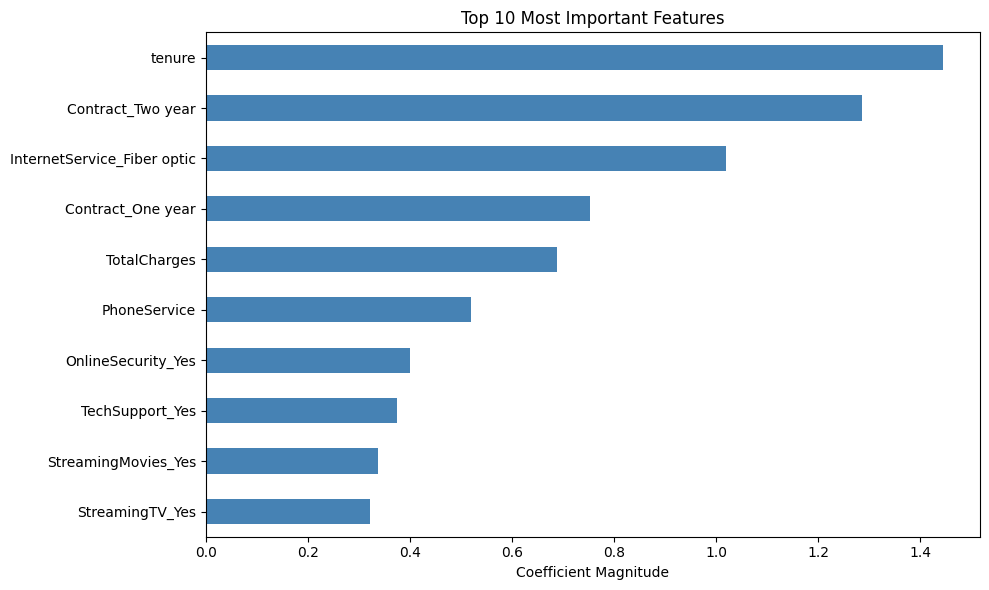

In [4]:
# Save the best model
joblib.dump(lr, '../models/churn_model.pkl')
print("Model saved!")

# Feature importance (using coefficients for Logistic Regression)
importance = pd.Series(np.abs(lr.coef_[0]), index=X_train.columns)
top10 = importance.nlargest(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features')
plt.xlabel('Coefficient Magnitude')
plt.tight_layout()
plt.show()

In [5]:
# Score full dataset
df_full = pd.read_csv('../data/telco_churn_cleaned.csv')

# Encode same as before
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_full = pd.get_dummies(df_full, columns=cat_cols, drop_first=True)

# Scale numeric cols
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = joblib.load('../models/scaler.pkl')
df_full[numeric_cols] = scaler.transform(df_full[numeric_cols])

# Get features (drop Churn)
X_full = df_full.drop(columns=['Churn'])

# Predict
df_full['churn_probability'] = lr.predict_proba(X_full)[:, 1]
df_full['churn_prediction'] = lr.predict(X_full)

# Export
df_full.to_csv('../data/scored_customers.csv', index=False)
print("Scored dataset saved!")
print(df_full[['Churn', 'churn_probability']].head(10))

Scored dataset saved!
   Churn  churn_probability
0      0           0.640305
1      0           0.038516
2      1           0.285561
3      0           0.025734
4      1           0.687686
5      1           0.788843
6      0           0.461936
7      0           0.300093
8      1           0.609005
9      0           0.009656


/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vadlamudikaavya/Desktop/churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni